## Flight Price Analysis

## Download Data

### Uncomment and run for the first time you worked with the dataset

In [1]:
import kagglehub
import os
from pathlib import Path
import duckdb
import pandas as pd

c:\Users\alnli\miniforge3\envs\flight-analysis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# os.environ['KAGGLE_API_TOKEN'] = 'KGAT_58eef09ae0e1a90b67503f337bb73a06'
# path = kagglehub.dataset_download("dilwong/flightprices",
#                                   path='itineraries.csv',
#                                   output_dir="../data",
#                                   force_download=True)

SSLError: HTTPSConnectionPool(host='api.kaggle.com', port=443): Max retries exceeded with url: /v1/datasets.DatasetApiService/GetDataset (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1016)')))

In [ ]:
# import zipfile
# # Extract the ZIP file
# zip_path = "../data/itineraries.csv"
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall("../data")

## Load in Data and Constuct Dataset:
Filter for data of interests: flights to ORD.
Set aside LAX to ORD flights for test set.

In [2]:
data_dir = Path("../data")
csv_path = data_dir / "itineraries.csv"
all_ord_parquet_path = data_dir / "flights_to_ORD_all.parquet"
ord_parquet_path = data_dir / "flights_to_ORD.parquet"
lax_parquet_path = data_dir / "flights_LAX_to_ORD.parquet"
bos_parquet_path = data_dir / "flights_BOS_to_ORD.parquet"

In [ ]:
# # Prepare the columns to keep and the date columns to parse
# col_list = [
#     "legId",
#     "searchDate",
#     "flightDate",
#     "startingAirport",
#     "destinationAirport",
#     "fareBasisCode",
#     "isBasicEconomy",
#     "isRefundable",
#     "baseFare",
#     "totalFare",
#     "seatsRemaining",
#     "segmentsDepartureTimeRaw",
#     "segmentsAirlineName",
#     "segmentsCabinCode",
# ]

In [ ]:
# # Use DuckDB to read the CSV once, then derive parquet slices from parquet.
# con = duckdb.connect()
# select_cols = ",\n    ".join(col_list)
# source_csv = csv_path.as_posix()

# print('Constructing all flights to ORD...')
# con.execute(f"""
# COPY (
#     SELECT {select_cols}
#     FROM read_csv_auto('{source_csv}', header=true, sample_size=-1)
#     WHERE destinationAirport = 'ORD'
# ) TO '{all_ord_parquet_path.as_posix()}' (FORMAT PARQUET);
# """)

# print('Constructing train set...')
# con.execute(f"""
# COPY (
#     SELECT {select_cols}
#     FROM read_parquet('{all_ord_parquet_path.as_posix()}')
#     WHERE startingAirport NOT IN ('LAX', 'BOS')
# ) TO '{ord_parquet_path.as_posix()}' (FORMAT PARQUET);
# """)

# print('Constructing LAX to ORD...')
# con.execute(f"""
# COPY (
#     SELECT {select_cols}
#     FROM read_parquet('{all_ord_parquet_path.as_posix()}')
#     WHERE startingAirport = 'LAX'
# ) TO '{lax_parquet_path.as_posix()}' (FORMAT PARQUET);
# """)

# print('Constructing BOS to ORD...')
# con.execute(f"""
# COPY (
#     SELECT {select_cols}
#     FROM read_parquet('{all_ord_parquet_path.as_posix()}')
#     WHERE startingAirport = 'BOS'
# ) TO '{bos_parquet_path.as_posix()}' (FORMAT PARQUET);
# """)

# con.close()

## Read Data and Preprocessing

In [3]:
flights_to_ORD = (pd.read_parquet(ord_parquet_path))
flights_LAX_to_ORD = (pd.read_parquet(lax_parquet_path))
flights_BOS_to_ORD = (pd.read_parquet(bos_parquet_path))
print(f"Num of Flights to ORD: {flights_to_ORD.shape}")
print(f"Num of Flights from LAX to ORD: {flights_LAX_to_ORD.shape}")
print(f"Num of Flights from BOS to ORD: {flights_BOS_to_ORD.shape}")

Num of Flights to ORD: (4632218, 14)
Num of Flights from LAX to ORD: (620576, 14)
Num of Flights from BOS to ORD: (464905, 14)


In [4]:
date_cols = ["searchDate", "flightDate"]
def _ensure_datetime_cols(df: pd.DataFrame) -> pd.DataFrame:
    """Parquet stores datetimes natively; parse_dates does not apply (unlike read_csv). Coerce date_cols after load if needed."""
    for c in date_cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c])
    return df

flights_to_ORD = _ensure_datetime_cols(flights_to_ORD)
flights_LAX_to_ORD = _ensure_datetime_cols(flights_to_ORD)
flights_BOS_to_ORD = _ensure_datetime_cols(flights_BOS_to_ORD)

In [ ]:
# # Ask Copilot: discard a dataframe and free up Python memory.
# import gc

# # flights_to_ORD is already the train set (excludes LAX/BOS), so keep it
# del flights_to_ORD
# del flights_LAX_to_ORD
# del flights_BOS_to_ORD
# gc.collect()

3301

In [5]:
def add_features(data):
    holiday_list = [
        pd.Timestamp(2022, 5, 30), # President's Day
        pd.Timestamp(2022, 6, 20), # Juneteenth
        pd.Timestamp(2022, 7, 4), # Independency Day
        pd.Timestamp(2022, 9, 5), # Labor Day
        pd.Timestamp(2022, 11, 11), # Veteran's Day
    ]
    data['days_until_departure'] = (data['flightDate'] - data['searchDate']).dt.days
    data['day_of_week_departure'] = data['flightDate'].dt.dayofweek
    data['is_holiday'] = data['flightDate'].isin(holiday_list)
    return data

In [6]:
flights_to_ORD = add_features(flights_to_ORD)
flights_LAX_to_ORD = add_features(flights_LAX_to_ORD)
flights_BOS_to_ORD = add_features(flights_BOS_to_ORD)

In [7]:
flights_to_ORD.describe()

,searchDate,flightDate,baseFare,totalFare,seatsRemaining,days_until_departure,day_of_week_departure
count,4632218,4632218,4.632218e+06,4.632218e+06,4.632218e+06,4.632218e+06,4.632218e+06
mean,2022-07-14 18:57:53,2022-08-10 15:43:27,2.517804e+02,2.961199e+02,6.051094e+00,2.686498e+01,2.824889e+00
min,2022-04-16 00:00:00,2022-04-17 00:00:00,4.100000e-01,1.959000e+01,0.000000e+00,1.000000e+00,0.000000e+00
25%,2022-06-06 00:00:00,2022-07-03 00:00:00,1.386000e+02,1.726000e+02,4.000000e+00,1.300000e+01,1.000000e+00
50%,2022-07-17 00:00:00,2022-08-16 00:00:00,2.027900e+02,2.446000e+02,7.000000e+00,2.600000e+01,3.000000e+00
75%,2022-08-24 00:00:00,2022-09-19 00:00:00,3.414000e+02,3.907000e+02,9.000000e+00,4.000000e+01,4.000000e+00
max,2022-10-05 00:00:00,2022-11-19 00:00:00,2.947910e+03,3.197100e+03,1.000000e+01,6.000000e+01,6.000000e+00
std,NaN,NaN,1.628961e+02,1.744243e+02,2.934209e+00,1.633492e+01,1.954314e+00


For the five flights that fit the following criteria, plot price change for days until departure:
1. Departure city: 'SFO'
2. Flight Date: 2022/06/28
3. Type: direct flights with normal cabi

In [9]:
flightDate_of_interest = flights_to_ORD[flights_to_ORD['flightDate'] == '2022-06-28']
flightDate_of_interest.shape

(24521, 17)

In [12]:
flights_at_60_days = (flightDate_of_interest[flightDate_of_interest['days_until_departure'] == 60]
            .sort_values('baseFare', ascending=False)
            .query("startingAirport == 'SFO'"))
flights_at_60_days = flights_at_60_days[~flights_at_60_days['segmentsCabinCode'].str.contains('||', regex=False)]
flights_at_60_days = flights_at_60_days[~flights_at_60_days['segmentsCabinCode'].str.contains('premium', regex=False)]
flights_at_60_days.shape

(13, 17)

In [26]:
# legId_to_filter = flights_at_60_days['legId'].iloc[:5].to_list()
first_rows = flights_at_60_days[flights_at_60_days['legId'].isin(legId_to_filter)].drop_duplicates(subset='legId', keep='first')#[['legId', 'segmentsDepartureTimeRaw']]
first_rows

,legId,searchDate,flightDate,startingAirport,destinationAirport,fareBasisCode,isBasicEconomy,isRefundable,baseFare,totalFare,seatsRemaining,segmentsDepartureTimeRaw,segmentsAirlineName,segmentsCabinCode,days_until_departure,day_of_week_departure,is_holiday
342397,afbfa3e4953d1ee15e9a933d96cef449,2022-04-29,2022-06-28,SFO,ORD,MAA0OKEY,False,False,692.09,758.60,9,2022-06-28T08:30:00.000-07:00,United,coach,60,1,False
342388,b5fa3c37d465b9dd778db4d4cbf01516,2022-04-29,2022-06-28,SFO,ORD,EAA0PKEY,False,False,540.47,595.61,6,2022-06-28T23:59:00.000-07:00,United,coach,60,1,False
342384,66451051d811800982f65fd826c646fd,2022-04-29,2022-06-28,SFO,ORD,K7AKZNN1,False,False,413.02,458.60,7,2022-06-28T13:06:00.000-07:00,American Airlines,coach,60,1,False
342378,3e78640565ca27c3b108188f8ff45763,2022-04-29,2022-06-28,SFO,ORD,HAA0OKEN,False,False,385.12,428.60,3,2022-06-28T06:33:00.000-07:00,United,coach,60,1,False
342379,a60fe622466729d30111a421be7c6310,2022-04-29,2022-06-28,SFO,ORD,HAA0OKEN,False,False,385.12,428.60,9,2022-06-28T16:45:00.000-07:00,United,coach,60,1,False


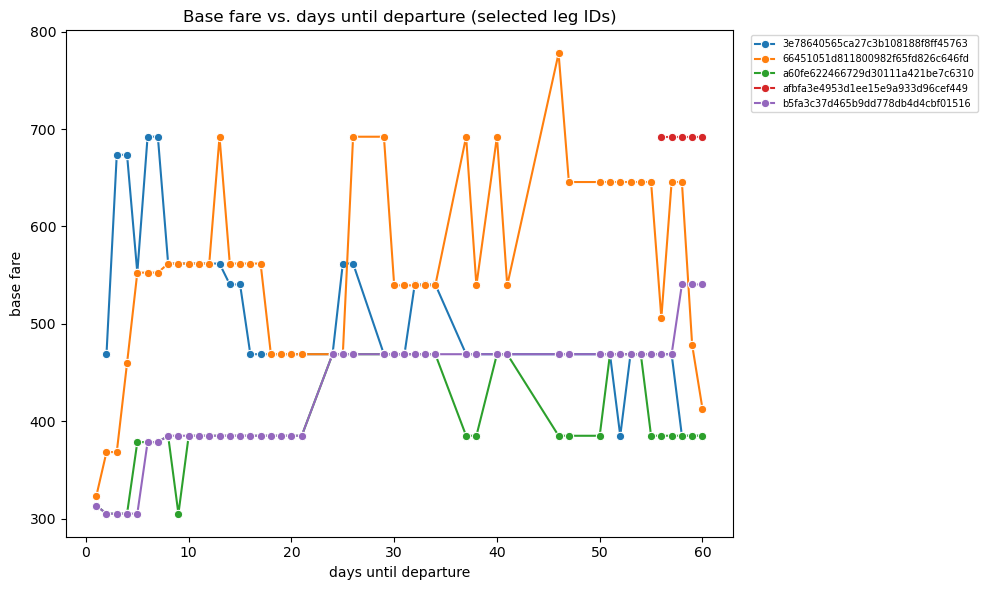

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

filtered_flight_date = flightDate_of_interest[
    flightDate_of_interest["legId"].isin(legId_to_filter)
].sort_values(["legId", "days_until_departure"])

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=filtered_flight_date,
    x="days_until_departure",
    y="baseFare",
    hue="legId",
    marker="o",
    ax=ax,
)
ax.set_xlabel("days until departure")
ax.set_ylabel("base fare")
ax.set_title("Base fare vs. days until departure (selected leg IDs)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()

Morning flights:
- `3e78640565ca27c3b108188f8ff45763`: flight prices are low around 2 months out, then drops between 16-20 days before departure. Dropped to the lowest within 4 days before departure.
- `afbfa3e4953d1ee15e9a933d96cef449`: not much insights, since only 5 datapoints.

Afternoon flights:
- `66451051d811800982f65fd826c646fd`: flight prices are low more than 2 months out, but quickly spikes. It drops to a low point 18-21 days before departure, and to the lowest within 4 days.
- `a60fe622466729d30111a421be7c6310`: flight price keeps dropping, except a spike between day 22-36. Maybe because arriving late.

Late night flight:
- `b5fa3c37d465b9dd778db4d4cbf01516`: flight price keeps dropping, because of late night flight.


In [25]:
# Find the lowest fare of this flight:
filtered_flight_date[filtered_flight_date['legId'] == 'a60fe622466729d30111a421be7c6310'].sort_values(["totalFare", "days_until_departure"])[["totalFare", "seatsRemaining", "fareBasisCode", "days_until_departure"]].head(30)

,totalFare,seatsRemaining,fareBasisCode,days_until_departure
1642101,342.6,9,QAA3JKEN,2
1614004,342.6,4,QAA3JKEN,3
1590955,342.6,7,QAA3JKEN,4
1475252,342.6,2,QAA3JKEN,9
1671627,351.6,9,QAA0AHEN,1
1573845,421.6,4,HAA0JHEN,5
1549336,421.6,7,HAA0JHEN,6
1523305,421.6,5,HAA0JHEN,7
1501172,428.6,9,HAA0OKEN,8
1447263,428.6,9,HAA0OKEN,10
